<a href="https://colab.research.google.com/github/episode16/Py/blob/master/DLS_mipt/game_of_thrones_hw1/hw_1_game_of_thrones_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

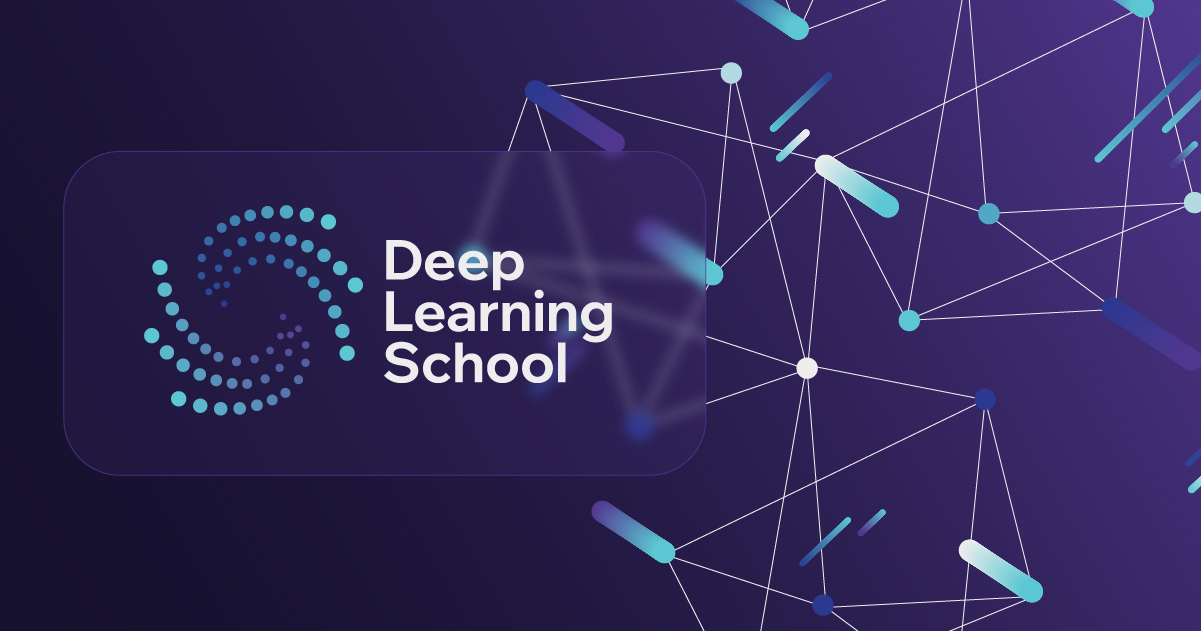

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

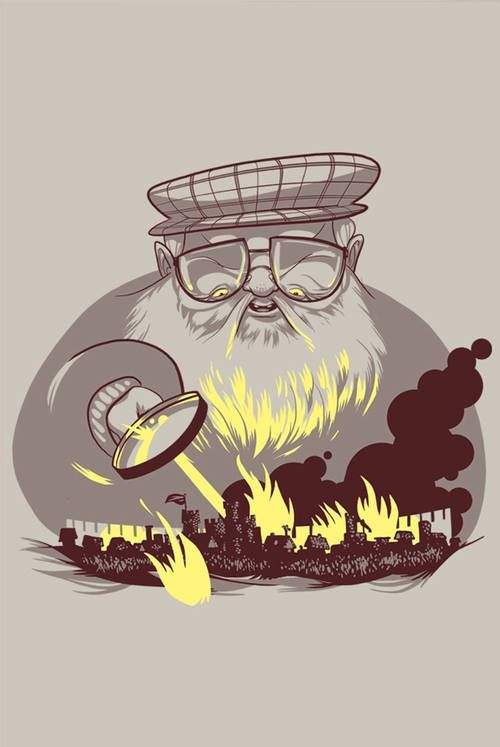

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [127]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 77.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 77.5MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [129]:
df = pd.read_csv('/content/game_of_thrones_train.csv', index_col = 'S.No')

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [131]:
df.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [132]:
df['isPopular'] = df['popularity']
df.loc[df['isPopular'] <= 0.5, 'isPopular'] = 0
df.loc[df['isPopular'] > 0.5, 'isPopular'] = 1

In [133]:
df['boolDeadRelations'] = df['numDeadRelations']
df.loc[df['boolDeadRelations'] > 0, 'boolDeadRelations'] = 1

In [134]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}
replacement_dict = {}
for main_name, variants in cult.items():
    for variant in variants:
        replacement_dict[variant] = main_name

def replace_culture(value):
    value_str = str(value).lower().strip()
    if value_str in replacement_dict:
        return replacement_dict[value_str]
    else:
        return value

df['culture'] = df['culture'].apply(replace_culture)
df['culture'].value_counts()

,count
culture,
Northmen,103
Ironborn,91
Free Folk,56
Braavosi,40
Valyrian,28
Dornish,21
Ghiscari,18
Dothraki,17
Westermen,14


Проверим какое количество данных отсутствует в каждом столбце

<BarContainer object of 27 artists>

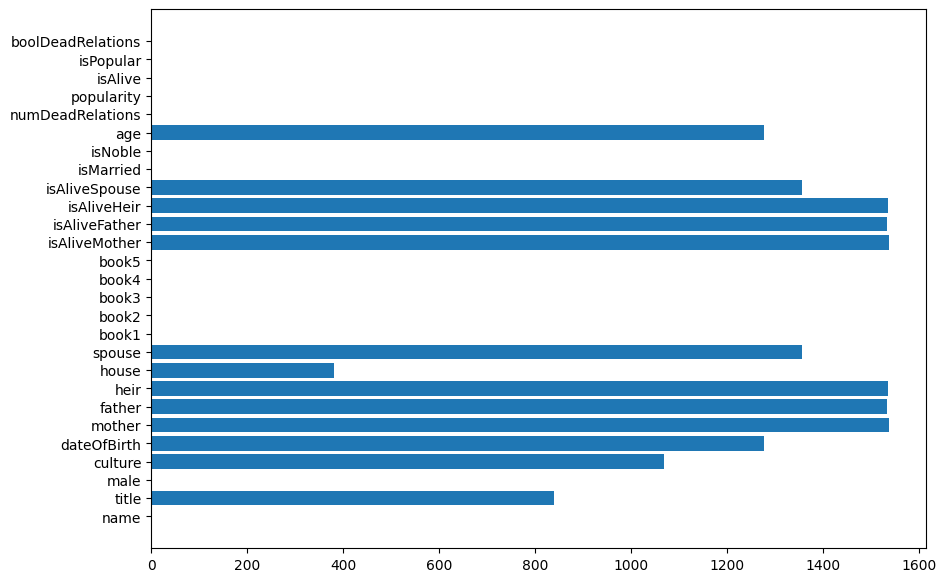

In [135]:
data = df.isna().sum()
plt.figure(figsize=(10,7))

plt.barh(data.index, data.values)

In [136]:
columns = df.columns
column_del = []
for column in columns:
  na_percentage = round((df[column].isna().sum() / len(df[column])) * 100, 3)
  print(f'{na_percentage} % пропущенных данных у признака {column}')
  if na_percentage > 87: # добавляем поля, где отсутствуют данные более чем 87%
    column_del.append(column)

column_del

0.0 % пропущенных данных у признака name
53.95 % пропущенных данных у признака title
0.0 % пропущенных данных у признака male
68.658 % пропущенных данных у признака culture
82.081 % пропущенных данных у признака dateOfBirth
98.844 % пропущенных данных у признака mother
98.587 % пропущенных данных у признака father
98.651 % пропущенных данных у признака heir
24.47 % пропущенных данных у признака house
87.155 % пропущенных данных у признака spouse
0.0 % пропущенных данных у признака book1
0.0 % пропущенных данных у признака book2
0.0 % пропущенных данных у признака book3
0.0 % пропущенных данных у признака book4
0.0 % пропущенных данных у признака book5
98.844 % пропущенных данных у признака isAliveMother
98.587 % пропущенных данных у признака isAliveFather
98.651 % пропущенных данных у признака isAliveHeir
87.155 % пропущенных данных у признака isAliveSpouse
0.0 % пропущенных данных у признака isMarried
0.0 % пропущенных данных у признака isNoble
82.081 % пропущенных данных у признака a

['mother',
 'father',
 'heir',
 'spouse',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse']

Можно заметить, что у столбцов mother, father, heir, isAliveMother, isAliveFather, isAliveHeir отсутствует большое количество данных (98.5%). Вместо этих столбцов можно обозначить 1 признак, который объединяет их всех по наличию родственника

но для этого добавим хорошо известный столбец isMarried для улучшения данных

In [137]:
for field in column_del:
  df.loc[(df[field].isnull()), ['relatives']] = 0
df.loc[(df[field].notnull()), ['relatives']] = 1
df['relatives'].head()

,relatives
S.No,
1,0.0
2,1.0
3,0.0
4,1.0
5,1.0


**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [138]:
df.drop(columns=column_del, inplace = True)

Поля age и dateOfBirth линейно зависимы. На их основе можно создать признак, который будет говорить о том, жив ли персонаж к 305 году.

In [139]:
# заполняю столбец isAlive_305 значениями -1 для nan
df['isAlive_305'] = -1

# Если dateOfBirth + age == 305 → жив (1)
alive_mask = (df['dateOfBirth'] + df['age'] == 305)
df.loc[alive_mask, 'isAlive_305'] = 1

# Если dateOfBirth + age < 305 → умер (0)
dead_mask = (df['dateOfBirth'] + df['age'] < 305)
df.loc[dead_mask, 'isAlive_305'] = 0

df['isAlive_305'].value_counts()

,count
isAlive_305,
-1,1278
1,189
0,90


Далее удаляем поля:
- age и dateOfBirth - заменили на isAlive_305
- numDeadRelations и popularity - заменили на boolDeadRelations и isPopular
- isAliveSpouse
- name - она не влияет на целевую переменную

In [140]:
df.drop(columns=['age', 'dateOfBirth', 'numDeadRelations', 'popularity', 'name'], inplace = True)

In [141]:
df.head()

,title,male,culture,house,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,relatives,isAlive_305
S.No,,,,,,,,,,,,,,,,
1,NaN,1,NaN,NaN,0,0,0,0,0,0,0,0,1.0,1,0.0,-1
2,Lord of the Crossing,1,Rivermen,House Frey,1,1,1,1,1,1,1,1,1.0,1,1.0,1
3,Ser,1,NaN,House Swyft,0,0,0,1,0,0,1,1,0.0,0,0.0,-1
4,Queen,0,NaN,House Arryn,0,0,0,0,0,1,1,0,0.0,0,1.0,0
5,Greenstone,0,Dornish,House Santagar,0,0,0,1,0,1,1,1,0.0,0,1.0,1


Здесь у нас остались признаки title (54% пропусков), culture (68% пропусков), house (24% пропусков).
Это категориальные признаки, их нужно сгруппировать в отдельные группы по типу "other", "unknown"

### Анализ title

title
Ser                  306
Maester               29
Archmaester           21
Lord                  19
Septon                16
                    ... 
Lord of Hellholt       1
Red Flower Vale        1
Lord of Harrenhal      1
Rain House             1
Highgarden             1
Name: count, Length: 195, dtype: int64

NaN значений: 840


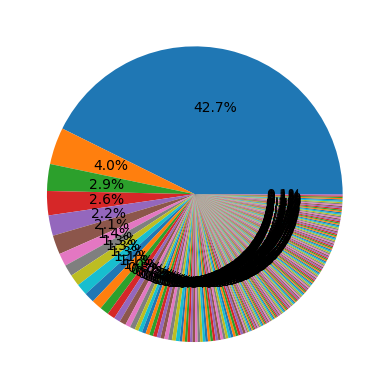

In [142]:
data_title = df['title'].value_counts()
print(data_title)
print('\nNaN значений:', df['title'].isna().sum())
plt.pie(data_title, autopct='%1.1f%%')

plt.show()

в данном случае видим, что титул "Ser" занимает 42% всех не nan значений. NaN значений 840, в сравнении с 306 "Ser", поэтому Nan значений заменим на unknown_title

In [143]:
df.loc[df.title.isnull(), ['title']] = 'unknown_title'

### Анализ culture

culture
Northmen                   103
Ironborn                    91
Free Folk                   56
Braavosi                    40
Valyrian                    28
Dornish                     21
Ghiscari                    18
Dothraki                    17
Westermen                   14
Reach                       13
Vale mountain clans         12
Rivermen                    10
Valemen                     10
Summer Islands               6
Qartheen                     6
Tyroshi                      6
Stormlander                  4
Astapori                     4
Northern mountain clans      3
Lysene                       3
Ironmen                      3
Westerosi                    3
Crannogmen                   2
Sistermen                    2
Andal                        2
Meereenese                   2
Myrish                       2
Lhazarene                    1
Qohor                        1
Norvoshi                     1
ironborn                     1
Lhazareen                    1


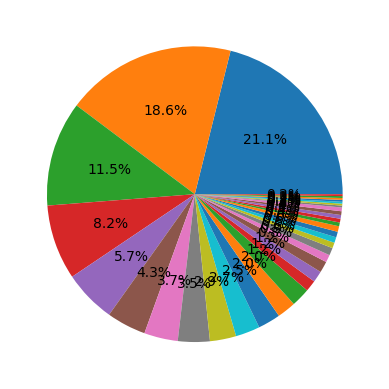

In [144]:
data_culture = df['culture'].value_counts()
print(data_culture)
print('\nNaN значений:', df['culture'].isna().sum())
plt.pie(data_culture, autopct='%1.1f%%')
plt.show()

Здесь же наибольшее значение culture - Northmen (109), а nan значений - 1069. Вообще данные о культуре кажутся не сбалансированными, однако можно попробовать объединить их в группу unknown_culture и посмотреть как модель обучается с ней

In [145]:
df.loc[df.culture.isnull(), ['culture']] = 'unknown_culture'

### Анализ house

house
House Frey                          89
Night's Watch                       88
House Stark                         56
House Targaryen                     40
House Lannister                     36
                                    ..
House Harlaw of Grey Garden          1
Summer Islands                       1
House Condon                         1
House Lannister of Casterly Rock     1
House Moore                          1
Name: count, Length: 315, dtype: int64
[89 88 56 40 36 33 30 20 15 12 11 10  9  8  7  6  5  4  3  2  1]

NaN значений: 381


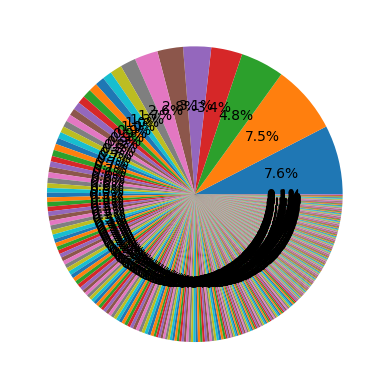

In [146]:
data_house = df['house'].value_counts()
print(data_house)
print(data_house.unique())
print('\nNaN значений:', df['house'].isna().sum())
plt.pie(data_house, autopct='%1.1f%%')

plt.show()

Здесь видим следующую ситуацию: nan значений - 381, House Frey - 89
Night's Watch 88. Также заметим, что можно объединить в группу дома, в которых значений мало. Можно построить расрпеделение по этим домам и посмотреть

count    315.000000
mean       3.733333
std        8.617417
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       89.000000
Name: count, dtype: float64


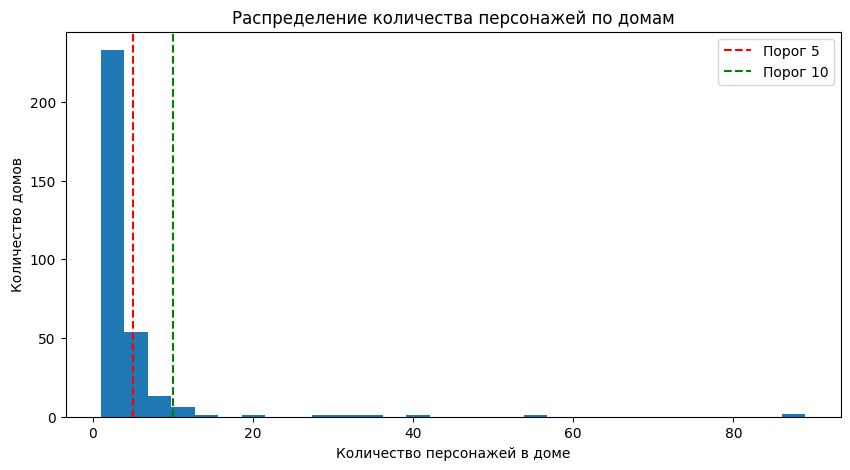

In [147]:
# Посмотрим статистику
print(data_house.describe())

# Визуализация распределения
plt.figure(figsize=(10, 5))
plt.hist(data_house, bins=30)
plt.title('Распределение количества персонажей по домам')
plt.xlabel('Количество персонажей в доме')
plt.ylabel('Количество домов')
plt.axvline(x=5, color='r', linestyle='--', label='Порог 5')
plt.axvline(x=10, color='g', linestyle='--', label='Порог 10')
plt.legend()
plt.show()

Столбчатая диаграмма была построена с порогами 5 и 10, чтобы оценить, в какой стороне находится перекос. Отсюда видно, что более 75% имеют менее 5 персонажей.
Таким образом можно сгруппировать значения меньше 5.

In [148]:
dict_house = dict(df['house'].value_counts())
rare_house = []
for house in dict_house.items():
  if house[1] < 5:
    rare_house.append(house[0])
rare_house

df['house'] = df['house'].replace(rare_house, 'less_5')

# nan аналогично title и culture
df.loc[df.house.isnull(), ['house']] = 'unknown_house'

Проверим остались ли nan значений в таблице

In [149]:
df.isna().sum()

,0
title,0
male,0
culture,0
house,0
book1,0
book2,0
book3,0
book4,0
book5,0
isMarried,0


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

In [150]:
df['isAlive'].describe()

,isAlive
count,1557.000000
mean,0.778420
std,0.415443
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


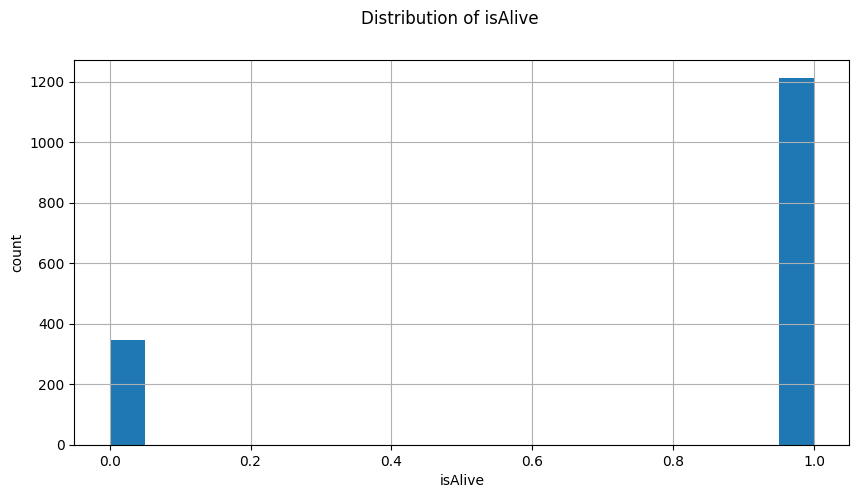

In [151]:
plt.figure(figsize = (10, 5))

df['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('isAlive')

plt.suptitle('Distribution of isAlive')
plt.show()

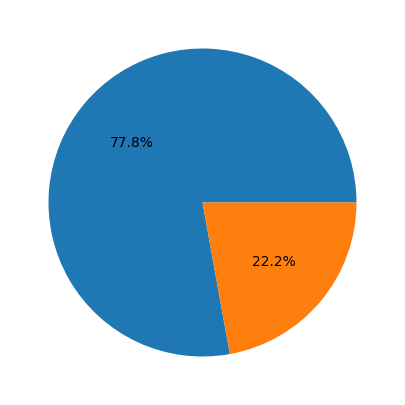

In [152]:
plt.figure(figsize = (10, 5))

data = df['isAlive'].value_counts()
plt.pie(data, autopct='%1.1f%%')
plt.show()

Видим на гистограмме, что умерших почти в 4 раза меньше чем живых. Можно ли назвать сбалансированным такой датасет - да.
Переменная категориальная (да/нет = 1/0)

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [153]:
categorical_columns = ['title', 'culture', 'house']
categorical_features = df[categorical_columns]

unprocessed_cat_features = categorical_features.select_dtypes(include=[object]).columns.tolist()

### One-hot encoding

In [154]:
from sklearn.preprocessing import OneHotEncoder

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=df.index
                          )

one_hot_df.head()

,title_Acorn Hall,title_Archmaester,title_Ashford,title_Banefort,title_Big BucketThe Wull,title_Bitterbridge,title_Blackcrown,title_Blackmont,title_Bloodrider,title_Blue Grace,...,house_House Westerling,house_House Whent,house_House Wylde,house_House of Loraq,house_Kingsguard,house_Night's Watch,house_Second Sons,house_Stone Crows,house_less_5,house_unknown_house
S.No,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [155]:
# Concatenate the one-hot encoded dataframe with the original dataframe
df_encoded = pd.concat([df, one_hot_df], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(unprocessed_cat_features, axis=1)

# Display the resulting dataframe
df_encoded

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,...,house_House Westerling,house_House Whent,house_House Wylde,house_House of Loraq,house_Kingsguard,house_Night's Watch,house_Second Sons,house_Stone Crows,house_less_5,house_unknown_house
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1,1,1,1,1,1,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,1,0,0,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,1,1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,0,0,0,1,0,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1554,0,1,1,0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1555,1,0,1,1,1,1,0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [156]:
df.columns

Index(['title', 'male', 'culture', 'house', 'book1', 'book2', 'book3', 'book4',
       'book5', 'isMarried', 'isNoble', 'isAlive', 'isPopular',
       'boolDeadRelations', 'relatives', 'isAlive_305'],
      dtype='object')

построим все возможные графики взаимных распределений всех признаков между собой

In [157]:
#sns.set()
#sns.pairplot(df_encoded, height = 2 ,kind ='scatter',diag_kind='kde') # взаимные графики на куче признаков
#plt.show()

Проверим как влияет титул на выжиываемость персонажа

In [158]:
unknown_title = df.loc[(df_encoded.title_unknown_title == 1), ["isAlive"]]
known_title = df_encoded.loc[(df_encoded.title_unknown_title == 0), ["isAlive"]]

In [159]:
print(unknown_title.sum())
print(known_title.sum())

isAlive    672
dtype: int64
isAlive    540
dtype: int64


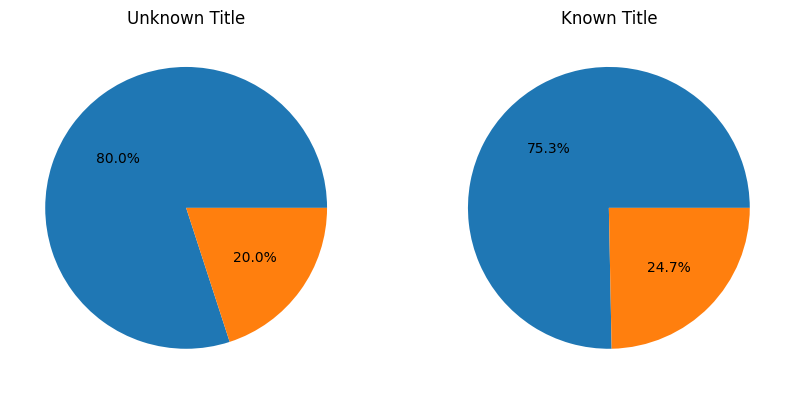

In [160]:
# Стоим круговую диаграмму
data_unknown_title = unknown_title.value_counts()
data_known_title = known_title.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(data_unknown_title, autopct='%1.1f%%')
ax2.pie(data_known_title, autopct='%1.1f%%')

ax1.set_title("Unknown Title")
ax2.set_title("Known Title")

plt.show()

Видим, что титул слабо влияет на выживаемость

Проверим, как наличие родственников влияет на выживаемость

<function matplotlib.pyplot.show(close=None, block=None)>

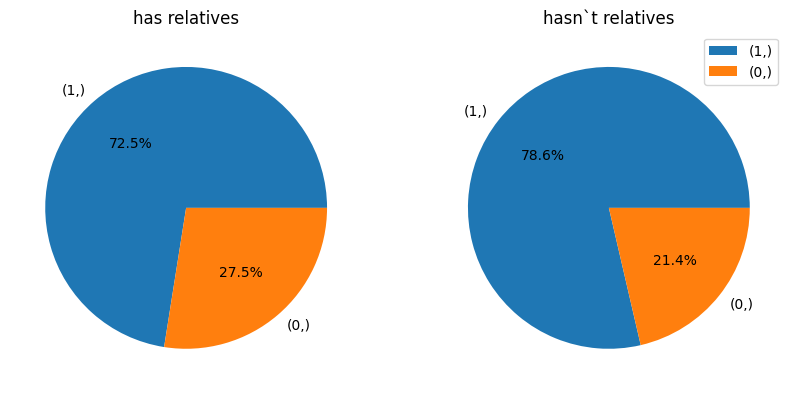

In [161]:
hasRelatives = df.loc[(df.relatives == 1), ["isAlive"]]
notRelatives = df.loc[(df.relatives == 0), ["isAlive"]]

d = hasRelatives.value_counts()
d1 = notRelatives.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(d, labels=d.index, autopct='%1.1f%%')
ax2.pie(d1, labels=d1.index, autopct='%1.1f%%')

ax1.set_title("has relatives")
ax2.set_title("hasn`t relatives")
plt.legend()

plt.show

Проанализируем также столбец isMarried

<function matplotlib.pyplot.show(close=None, block=None)>

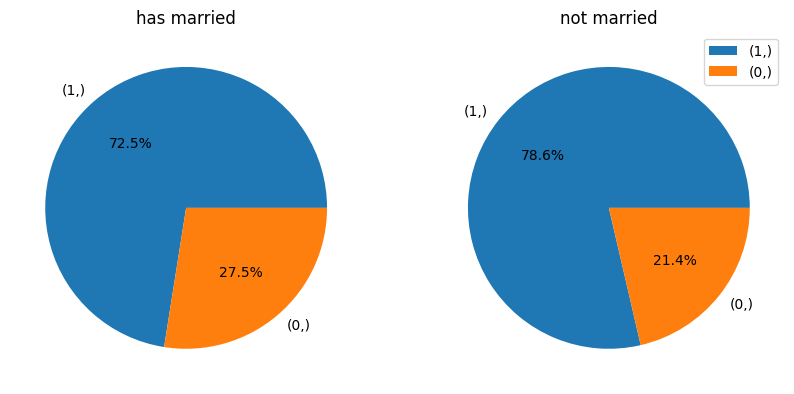

In [162]:
hasMarried = df.loc[(df.isMarried == 1), ["isAlive"]]
notMarried = df.loc[(df.isMarried == 0), ["isAlive"]]

d = hasMarried.value_counts()
d1 = notMarried.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(d, labels=d.index, autopct='%1.1f%%')
ax2.pie(d1, labels=d1.index, autopct='%1.1f%%')

ax1.set_title("has married")
ax2.set_title("not married")
plt.legend()

plt.show

Видим, что признаки relatives и isMarried напрямую коррелируют друг с другом, что плохо, поэтому избавимся от признака isMarried

In [163]:
df = df.drop(columns='isMarried')
df_encoded = df_encoded.drop(columns='isMarried')

Проверим насколько популярность влияет на выживаемость

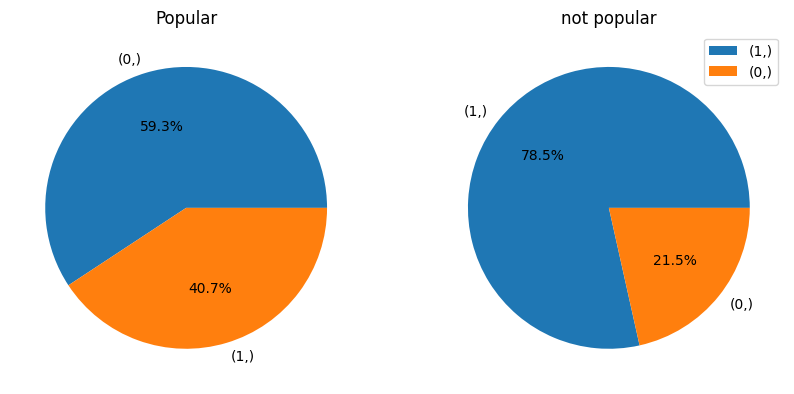

In [166]:
popular = df.loc[(df.isPopular == 1), ["isAlive"]]
not_popular = df.loc[(df.isPopular == 0), ["isAlive"]]

d = popular.value_counts()
d1 = not_popular.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(d, labels=d.index, autopct='%1.1f%%')
ax2.pie(d1, labels=d1.index, autopct='%1.1f%%')

ax1.set_title("Popular")
ax2.set_title("not popular")
plt.legend()

plt.show()

и заметим, что популярность хорошо влияет на выживаемость

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [167]:
X = df_encoded.drop(columns=['isAlive']).values
y = df_encoded['isAlive'].values

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.2, random_state=42)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [171]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [172]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [173]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

для удобства сразу посчитаем accuracy модели

### 2.3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

In [182]:
from sklearn.metrics import accuracy_score

In [183]:
# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7660


#### AdaBoostClassifier

In [184]:
model_ada = AdaBoostClassifier()
model_ada.fit(X_train, y_train)
y_pred = model_ada.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8269


#### RandomForestClassifier

In [185]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7885


#### GaussianProcessClassifier

In [186]:
model_gaussian = GaussianProcessClassifier()
model_gaussian.fit(X_train, y_train)
y_pred = model_gaussian.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7756


#### GaussianNB

In [187]:
model_gausianNB = GaussianNB()
model_gausianNB.fit(X_train, y_train)
y_pred = model_gausianNB.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.3526


#### KNeighborsClassifier

In [188]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred = model_knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7917


#### SVC

In [189]:
model_svc = SVC()
model_svc.fit(X_train, y_train)
y_pred = model_svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7917


#### DecisionTreeClassifier

In [190]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
y_pred = model_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7885


Выберите лучшую модель.

In [191]:
best_model = AdaBoostClassifier()

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [192]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.9MB/s]


In [193]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [194]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


проделываем абсолютно всё тоже ссамое для test.csv

In [ ]:
test_data = pd.read_csv("/content/game_of_thrones_test.csv", index_col="S.No")

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)